# Mineral GNN Training
Trains a GNN on the following tasks:
- Classification by chemical family (silicates, oxides, sulfides, etc.)
- Similarity retrieval; top-k nearest neighbors in embedding space

**Models:** MLP baseline vs 2-layer GraphSAGE

**Input:** `mineral_graph.pt` + `mineral_meta.pkl` from preprocessing `rruff_preprocessing_with_text_removal.ipynb`


In [ ]:
import torch, subprocess, sys

TORCH = torch.__version__.split('+')[0]
CUDA  = 'cu' + torch.version.cuda.replace('.', '')
PYG_URL = f"https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html"
print(f"Installing for torch-{TORCH}+{CUDA}...")

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "torch-geometric", "torch-scatter", "torch-sparse",
    "scikit-learn", "tqdm",
    "--find-links", PYG_URL,
], check=True)
print("Done.")

from google.colab import drive
drive.mount('/content/drive')
print(f"CUDA available: {torch.cuda.is_available()}")

Installing for torch-2.10.0+cu128...
Done.
Mounted at /content/drive
CUDA available: True


In [ ]:
!unzip /content/LR-Raman.zip -d /content/LR-Raman

Streaming output truncated to the last 5000 lines.
  inflating: /content/LR-Raman/Lefontite__R140428__Broad_Scan__532__0__unoriented__Raman_Data_Processed__427748dc880dfe82b3bf6ffdfbe7.txt  
  inflating: /content/LR-Raman/Lefontite__R140428__Broad_Scan__780__0__unoriented__Raman_Data_Processed__b00e601d702c8377ca0234505aef.txt  
  inflating: /content/LR-Raman/Lefontite__R140539__Broad_Scan__532__0__unoriented__Raman_Data_Processed__ac49a3f17c6132e72c5562ddbb9a.txt  
  inflating: /content/LR-Raman/Lefontite__R140539__Broad_Scan__780__0__unoriented__Raman_Data_Processed__ffed34377807ccde90e250746028.txt  
  inflating: /content/LR-Raman/Legrandite__R040151__Broad_Scan__532__0__unoriented__Raman_Data_Raw__dfda785b8e19da419602774c3e98.txt  
  inflating: /content/LR-Raman/Legrandite__R040151__Broad_Scan__785__0__unoriented__Raman_Data_Raw__0abda95df16c46811745ee5e001b.txt  
  inflating: /content/LR-Raman/Leifite__R060219__Broad_Scan__532__0__unoriented__Raman_Data_Raw__493cad23db8b6f9baf39a1

In [ ]:
import pickle
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

warnings.filterwarnings('ignore')

#drive location of preprocessing notebook outputs
BASE = Path("/content/drive/My Drive/Classes/2026 Spring/advanced ml/rruff_processed")

# Raman files are uploaded locally
RAMAN_DIR = Path("/content/LR-Raman")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

missing = []
if not BASE.exists():
    missing.append(str(BASE))
if not RAMAN_DIR.exists():
    missing.append(str(RAMAN_DIR))
if not (BASE /'mineral_graph.pt').exists():
    missing.append(str(BASE / 'mineral_graph.pt'))
if not (BASE /'mineral_meta.pkl').exists():
    missing.append(str(BASE / 'mineral_meta.pkl'))

if missing:
    raise FileNotFoundError(
        "Missing required inputs:\n" + "\n".join(f"  {p}" for p in missing)
    )
print("All required files found.")


Device: cuda
All required files found.


In [ ]:
#loads graph
data = torch.load(BASE / 'mineral_graph.pt', map_location='cpu', weights_only=False)
with open(BASE / 'mineral_meta.pkl', 'rb') as f:
    meta = pickle.load(f)

final_ids= meta['final_ids']       # list of RRUFF IDs in node order
mineral_names = meta['mineral_names']   # list of mineral names in node order

print(f"Nodes          : {data.num_nodes}")
print(f"Edges          : {data.num_edges}")
print(f"Feature dim    : {data.num_features}")
print(f"Original classes (species): {data.num_classes}")

Nodes          : 1264
Edges          : 227672
Feature dim    : 768
Original classes (species): 1264


In [ ]:
# assigns chemical family labels
'''
Parses chemical family from RRUFF Raman file headers - ##IDEAL CHEMISTRY field
Maps each mineral to one of 9 standard IMA chemical classes.
Rules are applied in priority order (most specific first).
'''

assert RAMAN_DIR.exists(), (
    f"LR-Raman not found at {RAMAN_DIR} — upload it to /content/ before running."
)

FAMILY_RULES = [
    ('Sulfides & Sulfosalts', r'(?<![A-Za-z])S(?!i|b|r|e|c|n|m|g|O|_4_)'),
    ('Silicates',             r'Si'),
    ('Carbonates',            r'CO_3_|\(CO_3\)'),
    ('Phosphates',            r'PO_4_|\(PO_4\)|PO_3_'),
    ('Sulfates',              r'SO_4_|\(SO_4\)'),
    ('Oxides & Hydroxides',   r'(?:^|[^A-Za-z])O(?:[^A-Za-z]|$)|\(OH\)'),
    ('Halides',               r'(?:^|[^A-Za-z])(?:Cl|Br|I|F)(?:[^a-z]|$)'),
    ('Borates',               r'BO_3_|BO_4_'),
    ('Native Elements',       r'^\s*[A-Z][a-z]?\s*$'),
]

CHEM_RE = re.compile(r'##IDEAL CHEMISTRY=(.+)')

# Build a fast lookup: RRUFF ID -> formula string
# We scan each file once and cache results
print("Building formula cache from Raman headers...")
id_to_formula = {}
for fpath in tqdm(list(RAMAN_DIR.glob('*.txt')), desc='Scanning Raman headers'):
    with open(fpath, 'r', errors='ignore') as fh:
        rruff_id = None
        formula = None
        for line in fh:
            if line.startswith('##RRUFFID='):
                rruff_id = line.strip().split('=', 1)[1].upper()
            elif line.startswith('##IDEAL CHEMISTRY='):
                m = CHEM_RE.match(line.strip())
                if m:
                    formula = m.group(1).strip()
            elif not line.startswith('#'):
                break
        if rruff_id and formula and rruff_id not in id_to_formula:
            id_to_formula[rruff_id] = formula

print(f"Cached formulas for {len(id_to_formula)} unique RRUFF IDs.")

def formula_to_family(formula):
    if not formula:
        return 'Other'
    for family, pattern in FAMILY_RULES:
        if re.search(pattern, formula):
            return family
    return 'Other'

families = [formula_to_family(id_to_formula.get(rid)) for rid in final_ids]

fam_counts = Counter(families)
print("\nChemical family distribution:")
for fam, count in sorted(fam_counts.items(), key=lambda x: -x[1]):
    print(f"  {fam:30s}: {count:4d}  ({count/len(families)*100:.1f}%)")
print(f"\nTotal families: {len(fam_counts)}")

# Warn if too many minerals landed in 'Other' (suggests formula parsing issue)
other_pct = fam_counts.get('Other', 0) / len(families) * 100
if other_pct > 20:
    print(f"\n{other_pct:.1f}% of minerals are 'Other' — check that RAMAN_DIR "
          f"contains the correct .txt files and that ##IDEAL CHEMISTRY= headers are present.")


Building formula cache from Raman headers...


Scanning Raman headers: 100%|██████████| 9941/9941 [00:00<00:00, 26333.70it/s]

Cached formulas for 3872 unique RRUFF IDs.

Chemical family distribution:
  Silicates                     :  398  (31.5%)
  Oxides & Hydroxides           :  304  (24.1%)
  Phosphates                    :  158  (12.5%)
  Other                         :  136  (10.8%)
  Sulfates                      :   94  (7.4%)
  Carbonates                    :   84  (6.6%)
  Sulfides & Sulfosalts         :   62  (4.9%)
  Native Elements               :   14  (1.1%)
  Halides                       :   11  (0.9%)
  Borates                       :    3  (0.2%)

Total families: 10


In [ ]:
# Encode labels & restratify split
from sklearn.model_selection import train_test_split

le_family = LabelEncoder()
family_labels = le_family.fit_transform(families)
n_family_classes = len(le_family.classes_)
print(f"Family classes : {n_family_classes}")
print(f"Classes        : {list(le_family.classes_)}")

data.y_family = torch.tensor(family_labels, dtype=torch.long)

N = data.num_nodes
indices = np.arange(N)

try:
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.2, random_state=42, stratify=family_labels)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, random_state=42, stratify=family_labels[temp_idx])


except ValueError:
    print("Stratified split failed, using random split.")
    train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42)
    val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_mask = torch.zeros(N, dtype=torch.bool)
val_mask   = torch.zeros(N, dtype=torch.bool)
test_mask  = torch.zeros(N, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask= test_mask

print(f"Train: {train_mask.sum().item()} | Val: {val_mask.sum().item()} | Test: {test_mask.sum().item()}")

Family classes : 10
Classes        : [np.str_('Borates'), np.str_('Carbonates'), np.str_('Halides'), np.str_('Native Elements'), np.str_('Other'), np.str_('Oxides & Hydroxides'), np.str_('Phosphates'), np.str_('Silicates'), np.str_('Sulfates'), np.str_('Sulfides & Sulfosalts')]
Train: 1011 | Val: 126 | Test: 127


In [ ]:
#model definitions

class MLP(nn.Module):
    """Baseline — no graph structure, node features only."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),)
        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index=None):
        return self.head(self.layers(x))

    def embed(self, x, edge_index=None):
        with torch.no_grad():
            h = self.layers(x)
        return F.normalize(h, dim=-1)


class GraphSAGE(nn.Module):
    """2-layer GraphSAGE."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.drop = nn.Dropout(dropout)
        self.head= nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        h = self.drop(F.relu(self.bn1(self.conv1(x, edge_index))))
        h = self.drop(F.relu(self.bn2(self.conv2(h, edge_index))))
        return self.head(h)

    def embed(self, x, edge_index):
        with torch.no_grad():
            h = F.relu(self.bn1(self.conv1(x, edge_index)))
            h = F.relu(self.bn2(self.conv2(h, edge_index)))
        return F.normalize(h, dim=-1)


IN_DIM = data.num_features   #512 (CLIP) + 256 (Raman PCA) = 768
HIDDEN_DIM = 256
OUT_DIM = n_family_classes

mlp = MLP(IN_DIM, HIDDEN_DIM, OUT_DIM).to(DEVICE)
sage = GraphSAGE(IN_DIM, HIDDEN_DIM, OUT_DIM).to(DEVICE)

print(f"MLP params  : {sum(p.numel() for p in mlp.parameters()):,}")
print(f"SAGE params : {sum(p.numel() for p in sage.parameters()):,}")

MLP params  : 266,250
SAGE params : 528,394


In [ ]:
# ── Cell 7: Training loop ─────────────────────────────────────────────────────

def train_model(model, data, label_key='y_family', lr=1e-3, epochs=300, patience=30):
    x          = data.x.to(DEVICE)
    edge_index = data.edge_index.to(DEVICE)
    y          = getattr(data, label_key).to(DEVICE)
    tr_mask    = data.train_mask.to(DEVICE)
    va_mask    = data.val_mask.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=15, factor=0.5)

    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0
    losses, val_accs = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out  = model(x, edge_index)
        loss = F.cross_entropy(out[tr_mask], y[tr_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(x, edge_index)[va_mask].argmax(-1).cpu().numpy()
            val_true = y[va_mask].cpu().numpy()
            val_acc  = accuracy_score(val_true, val_pred)

        scheduler.step(1 - val_acc)
        losses.append(loss.item())
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1

        if epoch % 50 == 0:
            print(f"  Epoch {epoch:3d} | loss {loss.item():.4f} | val_acc {val_acc:.4f} | best {best_val_acc:.4f}")

        if no_improve >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return losses, val_accs, best_val_acc


print("Training MLP baseline...")
mlp_losses, mlp_val_accs, mlp_best = train_model(mlp, data)
print(f"MLP best val accuracy: {mlp_best:.4f}")

print("\nTraining GraphSAGE...")
sage_losses, sage_val_accs, sage_best = train_model(sage, data)
print(f"GraphSAGE best val accuracy: {sage_best:.4f}")

Training MLP baseline...
  Epoch  50 | loss 0.3124 | val_acc 0.5556 | best 0.5794
  Early stopping at epoch 74
MLP best val accuracy: 0.5794

Training GraphSAGE...
  Epoch  50 | loss 0.2119 | val_acc 0.6111 | best 0.6111
  Early stopping at epoch 94
GraphSAGE best val accuracy: 0.6667


In [ ]:
# ── Cell 8: Test evaluation — Task A (Classification) ─────────────────────────

def evaluate(model, data, label_key='y_family'):
    model.eval()
    x  = data.x.to(DEVICE)
    ei = data.edge_index.to(DEVICE)
    y  = getattr(data, label_key).to(DEVICE)
    m  = data.test_mask.to(DEVICE)
    with torch.no_grad():
        pred = model(x, ei)[m].argmax(-1).cpu().numpy()
        true = y[m].cpu().numpy()
    return accuracy_score(true, pred), f1_score(true, pred, average='macro', zero_division=0), true, pred

mlp_acc,  mlp_f1,  mlp_true,  mlp_pred  = evaluate(mlp,  data)
sage_acc, sage_f1, sage_true, sage_pred = evaluate(sage, data)

print("=" * 55)
print("TASK A — Chemical Family Classification (Test Set)")
print("=" * 55)
print(f"{'Model':<18} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 40)
print(f"{'MLP (baseline)':<18} {mlp_acc:>10.4f} {mlp_f1:>10.4f}")
print(f"{'GraphSAGE':<18} {sage_acc:>10.4f} {sage_f1:>10.4f}")
print()
print("GraphSAGE per-class breakdown:")
present_labels = sorted(set(sage_true) | set(sage_pred))
print(classification_report(sage_true, sage_pred,
                             labels=present_labels,
                             target_names=[le_family.classes_[i] for i in present_labels],
                             zero_division=0))

TASK A — Chemical Family Classification (Test Set)
Model                Accuracy   Macro F1
----------------------------------------
MLP (baseline)         0.5591     0.3663
GraphSAGE              0.6693     0.4955

GraphSAGE per-class breakdown:
                       precision    recall  f1-score   support

           Carbonates       0.80      0.50      0.62         8
              Halides       0.00      0.00      0.00         1
      Native Elements       0.00      0.00      0.00         1
                Other       0.50      0.50      0.50        14
  Oxides & Hydroxides       0.61      0.81      0.69        31
           Phosphates       0.73      0.69      0.71        16
            Silicates       0.82      0.70      0.76        40
             Sulfates       0.50      0.70      0.58        10
Sulfides & Sulfosalts       0.75      0.50      0.60         6

             accuracy                           0.67       127
            macro avg       0.52      0.49      0.50      

In [ ]:
# ── Cell 9: Task B — Similarity Retrieval ─────────────────────────────────────
#
# For each test mineral, rank all other minerals by cosine similarity
# in the learned embedding space, then compute:
#   Family Recall@k  : does top-k contain a mineral of the same chemical family?
#   Species Recall@k : does top-k contain the exact same mineral species?
#   MRR              : mean reciprocal rank of first correct hit

def retrieval_eval(model, data, k_values=[1, 5, 10]):
    model.eval()
    x  = data.x.to(DEVICE)
    ei = data.edge_index.to(DEVICE)

    embs = model.embed(x, ei).cpu()        # (N, hidden_dim), L2-normalized
    sim  = embs @ embs.t()                 # (N, N) cosine similarities

    y_family  = data.y_family
    y_species = data.y              # original species labels
    test_idx  = data.test_mask.nonzero(as_tuple=True)[0].tolist()

    rec = {f'family_recall@{k}':  [] for k in k_values}
    rec.update({f'species_recall@{k}': [] for k in k_values})
    mrr_fam, mrr_spe = [], []

    for qi in test_idx:
        scores = sim[qi].clone()
        scores[qi] = -1.0
        ranked = scores.argsort(descending=True)

        tf = y_family[qi].item()
        ts = y_species[qi].item()

        for k in k_values:
            top_k = ranked[:k]
            rec[f'family_recall@{k}'].append(int(tf in y_family[top_k].tolist()))
            rec[f'species_recall@{k}'].append(int(ts in y_species[top_k].tolist()))

        fhits = (y_family[ranked] == tf).nonzero(as_tuple=True)[0]
        mrr_fam.append(1.0 / (fhits[0].item() + 1) if len(fhits) else 0.0)

        shits = (y_species[ranked] == ts).nonzero(as_tuple=True)[0]
        mrr_spe.append(1.0 / (shits[0].item() + 1) if len(shits) else 0.0)

    out = {k: np.mean(v) for k, v in rec.items()}
    out['family_MRR']  = np.mean(mrr_fam)
    out['species_MRR'] = np.mean(mrr_spe)
    return out


print("Computing retrieval metrics...")
mlp_ret  = retrieval_eval(mlp,  data)
sage_ret = retrieval_eval(sage, data)

print()
print("=" * 58)
print("TASK B — Similarity Retrieval (test queries vs. all nodes)")
print("=" * 58)
print(f"{'Metric':<25} {'MLP':>10} {'GraphSAGE':>12}")
print("-" * 50)
for m in ['family_recall@1', 'family_recall@5', 'family_recall@10',
           'family_MRR',
           'species_recall@1', 'species_recall@5', 'species_recall@10',
           'species_MRR']:
    print(f"{m:<25} {mlp_ret[m]:>10.4f} {sage_ret[m]:>12.4f}")

Computing retrieval metrics...

TASK B — Similarity Retrieval (test queries vs. all nodes)
Metric                           MLP    GraphSAGE
--------------------------------------------------
family_recall@1               0.5591       0.6220
family_recall@5               0.7323       0.7717
family_recall@10              0.8031       0.7874
family_MRR                    0.6401       0.6949
species_recall@1              0.0000       0.0000
species_recall@5              0.0000       0.0000
species_recall@10             0.0000       0.0000
species_MRR                   0.0008       0.0008


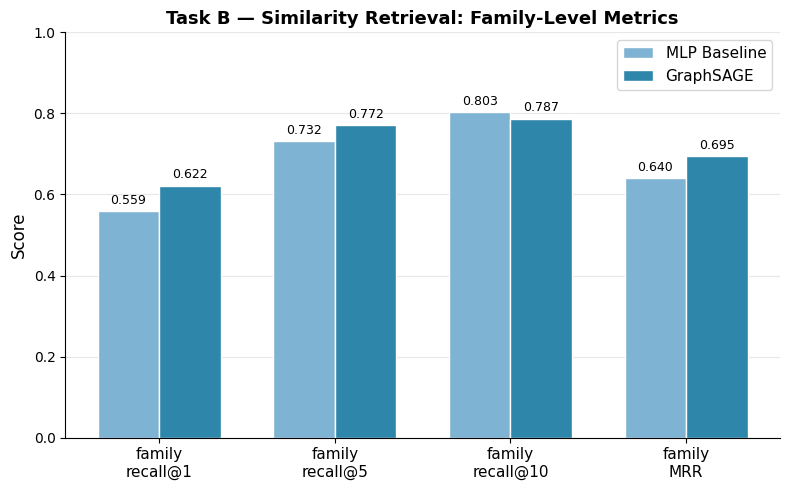

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['family\nrecall@1', 'family\nrecall@5', 'family\nrecall@10', 'family\nMRR']
mlp_vals  = [0.5591, 0.7323, 0.8031, 0.6401]
sage_vals = [0.6220, 0.7717, 0.7874, 0.6949]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_mlp  = ax.bar(x - width/2, mlp_vals,  width, label='MLP Baseline', color='#7fb3d3', edgecolor='white')
bars_sage = ax.bar(x + width/2, sage_vals, width, label='GraphSAGE',    color='#2e86ab', edgecolor='white')

# Value labels
for bar in bars_mlp + bars_sage:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Task B — Similarity Retrieval: Family-Level Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('task_b_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()

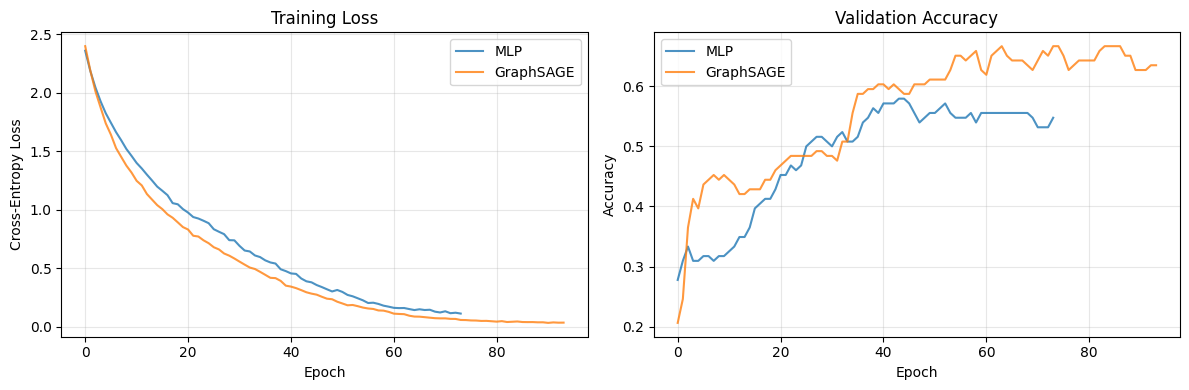

Saved training_curves.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp_losses,  label='MLP',       alpha=0.8)
axes[0].plot(sage_losses, label='GraphSAGE', alpha=0.8)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mlp_val_accs,  label='MLP',       alpha=0.8)
axes[1].plot(sage_val_accs, label='GraphSAGE', alpha=0.8)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(BASE / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_curves.png")

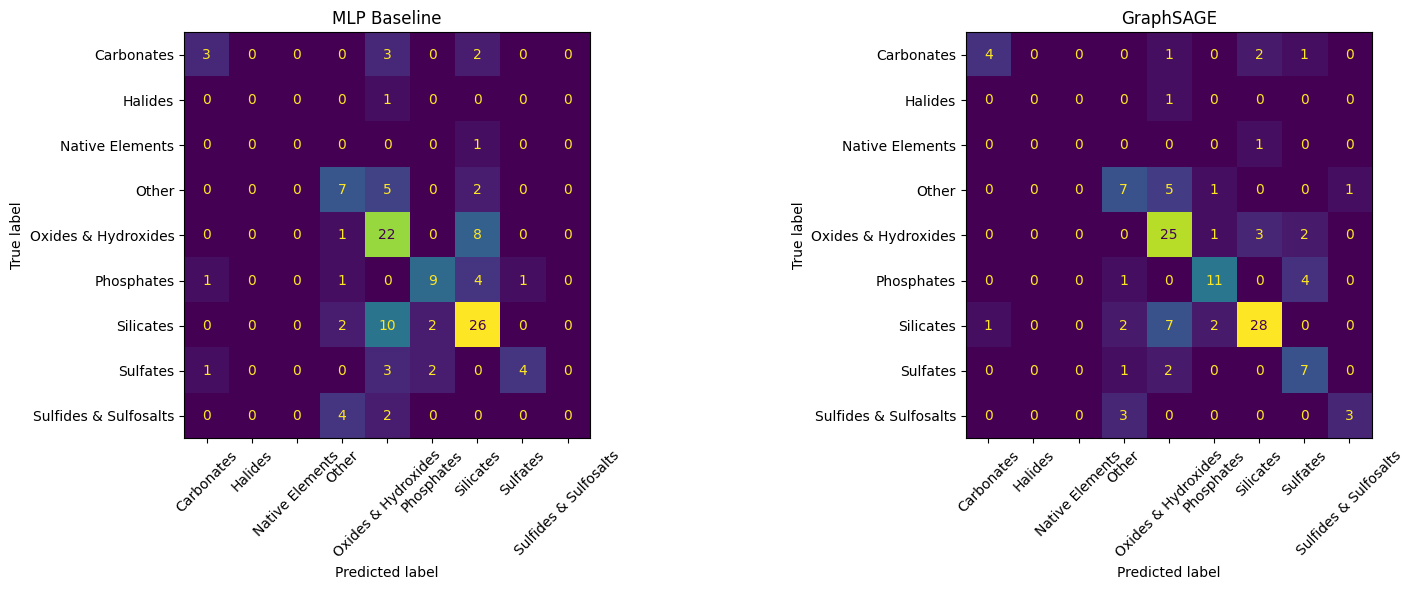

Saved confusion_matrices.png


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

present_labels = sorted(set(mlp_true) | set(mlp_pred) | set(sage_true) | set(sage_pred))
present_names  = [le_family.classes_[i] for i in present_labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, true, pred, title in [
    (axes[0], mlp_true,  mlp_pred,  'MLP Baseline'),
    (axes[1], sage_true, sage_pred, 'GraphSAGE'),
]:
    ConfusionMatrixDisplay.from_predictions(
        true, pred,
        labels=present_labels,
        display_labels=present_names,
        ax=ax, colorbar=False,
        xticks_rotation=45
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig(BASE / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion_matrices.png")

Fitting t-SNE (~1 min)...


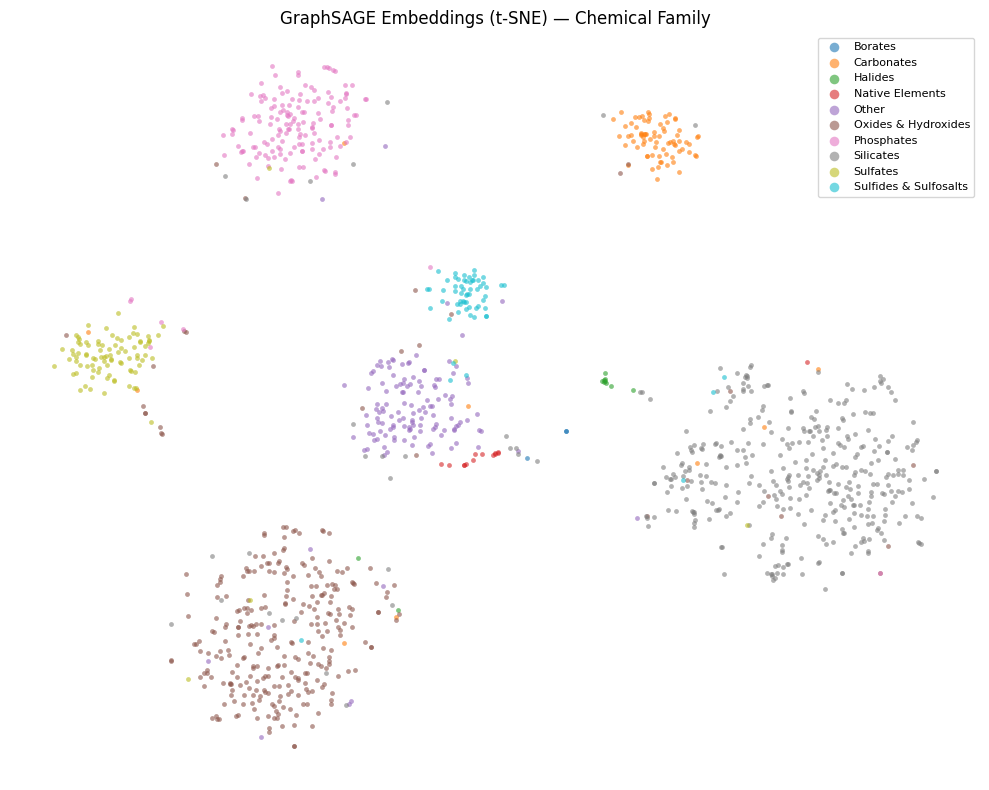

Saved tsne_embeddings.png


In [ ]:
#t-SNE visualization
from sklearn.manifold import TSNE
import matplotlib.cm as mplcm

sage.eval()
with torch.no_grad():
    embs_np = sage.embed(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu().numpy()

print("Fitting t-SNE (~1 min)...")
tsne    = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
embs_2d = tsne.fit_transform(embs_np)

cmap = mplcm.get_cmap('tab10', n_family_classes)
fig, ax = plt.subplots(figsize=(10, 8))
for i, fam in enumerate(le_family.classes_):
    mask = family_labels == i
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
               c=[cmap(i)], label=fam, alpha=0.6, s=12, linewidths=0)
ax.legend(markerscale=2, fontsize=8)
ax.set_title('GraphSAGE Embeddings (t-SNE) — Chemical Family')
ax.axis('off')
plt.tight_layout()
plt.savefig(BASE / 'tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tsne_embeddings.png")

In [ ]:
import random

sage.eval()
with torch.no_grad():
    all_embs = sage.embed(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu()
sim_matrix = all_embs @ all_embs.t()

test_idx = data.test_mask.nonzero(as_tuple=True)[0].tolist()
random.seed(7)
demo_queries = random.sample(test_idx, min(5, len(test_idx)))

print("=" * 72)
print("QUALITATIVE RETRIEVAL DEMO — Top-5 neighbors per query")
print("=" * 72)

for qi in demo_queries:
    scores = sim_matrix[qi].clone()
    scores[qi] = -1.0
    top5 = scores.argsort(descending=True)[:5].tolist()

    print(f"\nQuery : {mineral_names[qi]} ({final_ids[qi]}) — [{families[qi]}]")
    print(f"{'':1}{'Rank':<5} {'Mineral':<30} {'Family':<25} {'Sim':>6}")
    print("-" * 70)
    for rank, ni in enumerate(top5, 1):
        match = "✓" if families[ni] == families[qi] else " "
        print(f"{match}{rank:<5} {mineral_names[ni]:<30} {families[ni]:<25} {sim_matrix[qi,ni].item():.4f}")

QUALITATIVE RETRIEVAL DEMO — Top-5 neighbors per query

Query : Kentrolite (R060245) — [Silicates]
 Rank  Mineral                        Family                       Sim
----------------------------------------------------------------------
 1     Srebrodolskite                 Oxides & Hydroxides       0.9087
 2     Simonellite                    Other                     0.8686
 3     Bariopharmacosiderite          Oxides & Hydroxides       0.8635
 4     Metalodevite                   Oxides & Hydroxides       0.8393
 5     Arsendescloizite               Oxides & Hydroxides       0.8361

Query : Scottyite (R141116) — [Silicates]
 Rank  Mineral                        Family                       Sim
----------------------------------------------------------------------
 1     Fluornatromicrolite            Oxides & Hydroxides       0.8617
 2     Keyite                         Oxides & Hydroxides       0.8169
 3     Bobjonesite                    Sulfates                  0.7686
 4    

In [ ]:
#saves everything to Drive
import json

torch.save(mlp.state_dict(),  BASE / 'mlp_weights.pt')
torch.save(sage.state_dict(), BASE / 'sage_weights.pt')

results = {
    'task_A': {
        'MLP':       {'accuracy': float(mlp_acc),  'macro_f1': float(mlp_f1)},
        'GraphSAGE': {'accuracy': float(sage_acc), 'macro_f1': float(sage_f1)},
    },
    'task_B': {
        'MLP':       {k: float(v) for k, v in mlp_ret.items()},
        'GraphSAGE': {k: float(v) for k, v in sage_ret.items()},
    },
    'n_family_classes': n_family_classes,
    'class_names': list(le_family.classes_),
    'n_nodes': data.num_nodes,
    'n_edges': data.num_edges,
}
with open(BASE / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Saved to Drive: mlp_weights.pt, sage_weights.pt, results.json")
print("Figures:        training_curves.png, confusion_matrices.png, tsne_embeddings.png")
print()
print("=" * 52)
print("FINAL RESULTS SUMMARY")
print("=" * 52)
print(f"Task A — {n_family_classes}-class chemical family classification")
print(f"  MLP       accuracy={mlp_acc:.4f}  macro-F1={mlp_f1:.4f}")
print(f"  GraphSAGE accuracy={sage_acc:.4f}  macro-F1={sage_f1:.4f}")
print()
print(f"Task B — Retrieval ({data.num_nodes} nodes total)")
print(f"  {'Metric':<22} {'MLP':>8} {'SAGE':>8}")
for m in ['family_recall@1','family_recall@5','family_MRR','species_recall@5','species_MRR']:
    print(f"  {m:<22} {mlp_ret[m]:>8.4f} {sage_ret[m]:>8.4f}")

Saved to Drive: mlp_weights.pt, sage_weights.pt, results.json
Figures:        training_curves.png, confusion_matrices.png, tsne_embeddings.png

FINAL RESULTS SUMMARY
Task A — 10-class chemical family classification
  MLP       accuracy=0.5591  macro-F1=0.3663
  GraphSAGE accuracy=0.6693  macro-F1=0.4955

Task B — Retrieval (1264 nodes total)
  Metric                      MLP     SAGE
  family_recall@1          0.5591   0.6220
  family_recall@5          0.7323   0.7717
  family_MRR               0.6401   0.6949
  species_recall@5         0.0000   0.0000
  species_MRR              0.0008   0.0008


In [ ]:
import pickle, re, json
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

BASE      = Path("/content/drive/My Drive/Classes/2026 Spring/advanced ml/rruff_processed")
RAMAN_DIR = Path("/content/LR-Raman")   # local unzipped copy (faster than Drive)
IMAGE_DIR = Path("/content/drive/My Drive/Classes/2026 Spring/advanced ml/rruff_processed/rruff_clean_images")
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# ── 1. Load graph & metadata ──────────────────────────────────────────────────
print("Loading graph and metadata...")
data = torch.load(BASE / 'mineral_graph.pt', map_location='cpu', weights_only=False)
with open(BASE / 'mineral_meta.pkl', 'rb') as f:
    meta = pickle.load(f)
# Load results to get the full list of class names
with open(BASE / 'results.json', 'r') as f:
    results = json.load(f)

final_ids     = meta['final_ids']
mineral_names = meta['mineral_names']
print(f"  {data.num_nodes} nodes | {data.num_edges} edges | feature dim {data.num_features}")

# ── 2. Rebuild family labels (same logic as Cell 4) ───────────────────────────
FAMILY_RULES = [
    ('Sulfides & Sulfosalts', r'(?<![A-Za-z])S(?!i|b|r|e|c|n|m|g|O|_4_)'),
    ('Silicates',             r'Si'),
    ('Carbonates',            r'CO_3_|\\(CO_3\\)'),
    ('Phosphates',            r'PO_4_|\\(PO_4\\)|PO_3_'),
    ('Sulfates',              r'SO_4_|\\(SO_4\\)'),
    ('Oxides & Hydroxides',   r'(?:^|[^A-Za-z])O(?:[^A-Za-z]|$)|\\(OH\\)'),
    ('Halides',               r'(?:^|[^A-Za-z])(?:Cl|Br|I|F)(?:[^a-z]|$)'),
    ('Borates',               r'BO_3_|BO_4_'),
    ('Native Elements',       r'^\\s*[A-Z][a-z]?\\s*$'),
]
CHEM_RE = re.compile(r'##IDEAL CHEMISTRY=(.+)')

# Use local Raman dir if available (faster), fall back to Drive
raman_source = RAMAN_DIR if RAMAN_DIR.exists() else \
    Path("/content/drive/My Drive/Classes/2026 Spring/advanced ml/LR-Raman")
print(f"Scanning Raman headers from: {raman_source}")

id_to_formula = {}
for fpath in tqdm(list(raman_source.glob('*.txt')), desc='Raman headers'):
    with open(fpath, 'r', errors='ignore') as fh:
        rruff_id = formula = None
        for line in fh:
            if line.startswith('##RRUFFID='):
                rruff_id = line.strip().split('=', 1)[1].upper()
            elif line.startswith('##IDEAL CHEMISTRY='):
                m = CHEM_RE.match(line.strip())
                if m:
                    formula = m.group(1).strip()
            elif not line.startswith('#'):
                break
        if rruff_id and formula and rruff_id not in id_to_formula:
            id_to_formula[rruff_id] = formula

def formula_to_family(formula):
    if not formula:
        return 'Other'
    for family, pattern in FAMILY_RULES:
        if re.search(pattern, formula):
            return family
    return 'Other'

families      = [formula_to_family(id_to_formula.get(rid)) for rid in final_ids]

# Fit LabelEncoder using all class names from the original training run
le_family     = LabelEncoder()
le_family.fit(results['class_names'])
family_labels = le_family.transform(families)
n_family_classes = len(le_family.classes_)

data.y_family = torch.tensor(family_labels, dtype=torch.long)
print(f"  {n_family_classes} chemical families: {list(le_family.classes_)}")

# ── 3. Rebuild masks (same seed as Cell 5) ────────────────────────────────────
import numpy as np
from sklearn.model_selection import train_test_split

N       = data.num_nodes
indices = np.arange(N)
try:
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.2, random_state=42, stratify=family_labels)
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.5, random_state=42, stratify=family_labels[temp_idx])
except ValueError:
    train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42)
    val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_mask = torch.zeros(N, dtype=torch.bool)
val_mask   = torch.zeros(N, dtype=torch.bool)
test_mask  = torch.zeros(N, dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask
print(f"  Train {train_mask.sum()} | Val {val_mask.sum()} | Test {test_mask.sum()}")

# ── 4. Rebuild GraphSAGE architecture & load weights ─────────────────────────
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.drop  = nn.Dropout(dropout)
        self.head  = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        h = self.drop(F.relu(self.bn1(self.conv1(x, edge_index))))
        h = self.drop(F.relu(self.bn2(self.conv2(h, edge_index))))
        return self.head(h)

    def embed(self, x, edge_index):
        with torch.no_grad():
            h = F.relu(self.bn1(self.conv1(x, edge_index)))
            h = F.relu(self.bn2(self.conv2(h, edge_index)))
        return F.normalize(h, dim=-1)

sage = GraphSAGE(
    in_dim=data.num_features,
    hidden_dim=256,
    out_dim=n_family_classes
).to(DEVICE)

sage.load_state_dict(torch.load(BASE / 'sage_weights.pt', map_location=DEVICE))
sage.eval()
print("GraphSAGE weights loaded.")

# ── 5. Precompute embeddings & similarity matrix ──────────────────────────────
print("Computing embeddings & similarity matrix...")
with torch.no_grad():
    all_embs   = sage.embed(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu()
    all_logits = sage(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu()
    all_preds  = all_logits.argmax(dim=-1)

sim_matrix = all_embs @ all_embs.t()
print(f"sim_matrix shape: {sim_matrix.shape}")

print()
print("All variables restored. Cell 15 is ready to run.")

Device: cuda
Loading graph and metadata...
  1264 nodes | 227672 edges | feature dim 768
Scanning Raman headers from: /content/LR-Raman


Raman headers: 100%|██████████| 9941/9941 [00:00<00:00, 27972.70it/s]


  10 chemical families: [np.str_('Borates'), np.str_('Carbonates'), np.str_('Halides'), np.str_('Native Elements'), np.str_('Other'), np.str_('Oxides & Hydroxides'), np.str_('Phosphates'), np.str_('Silicates'), np.str_('Sulfates'), np.str_('Sulfides & Sulfosalts')]
  Train 1011 | Val 126 | Test 127
GraphSAGE weights loaded.
Computing embeddings & similarity matrix...
sim_matrix shape: torch.Size([1264, 1264])

All variables restored. Cell 15 is ready to run.


Building image path lookup...
Found images for 1895 unique RRUFF IDs.


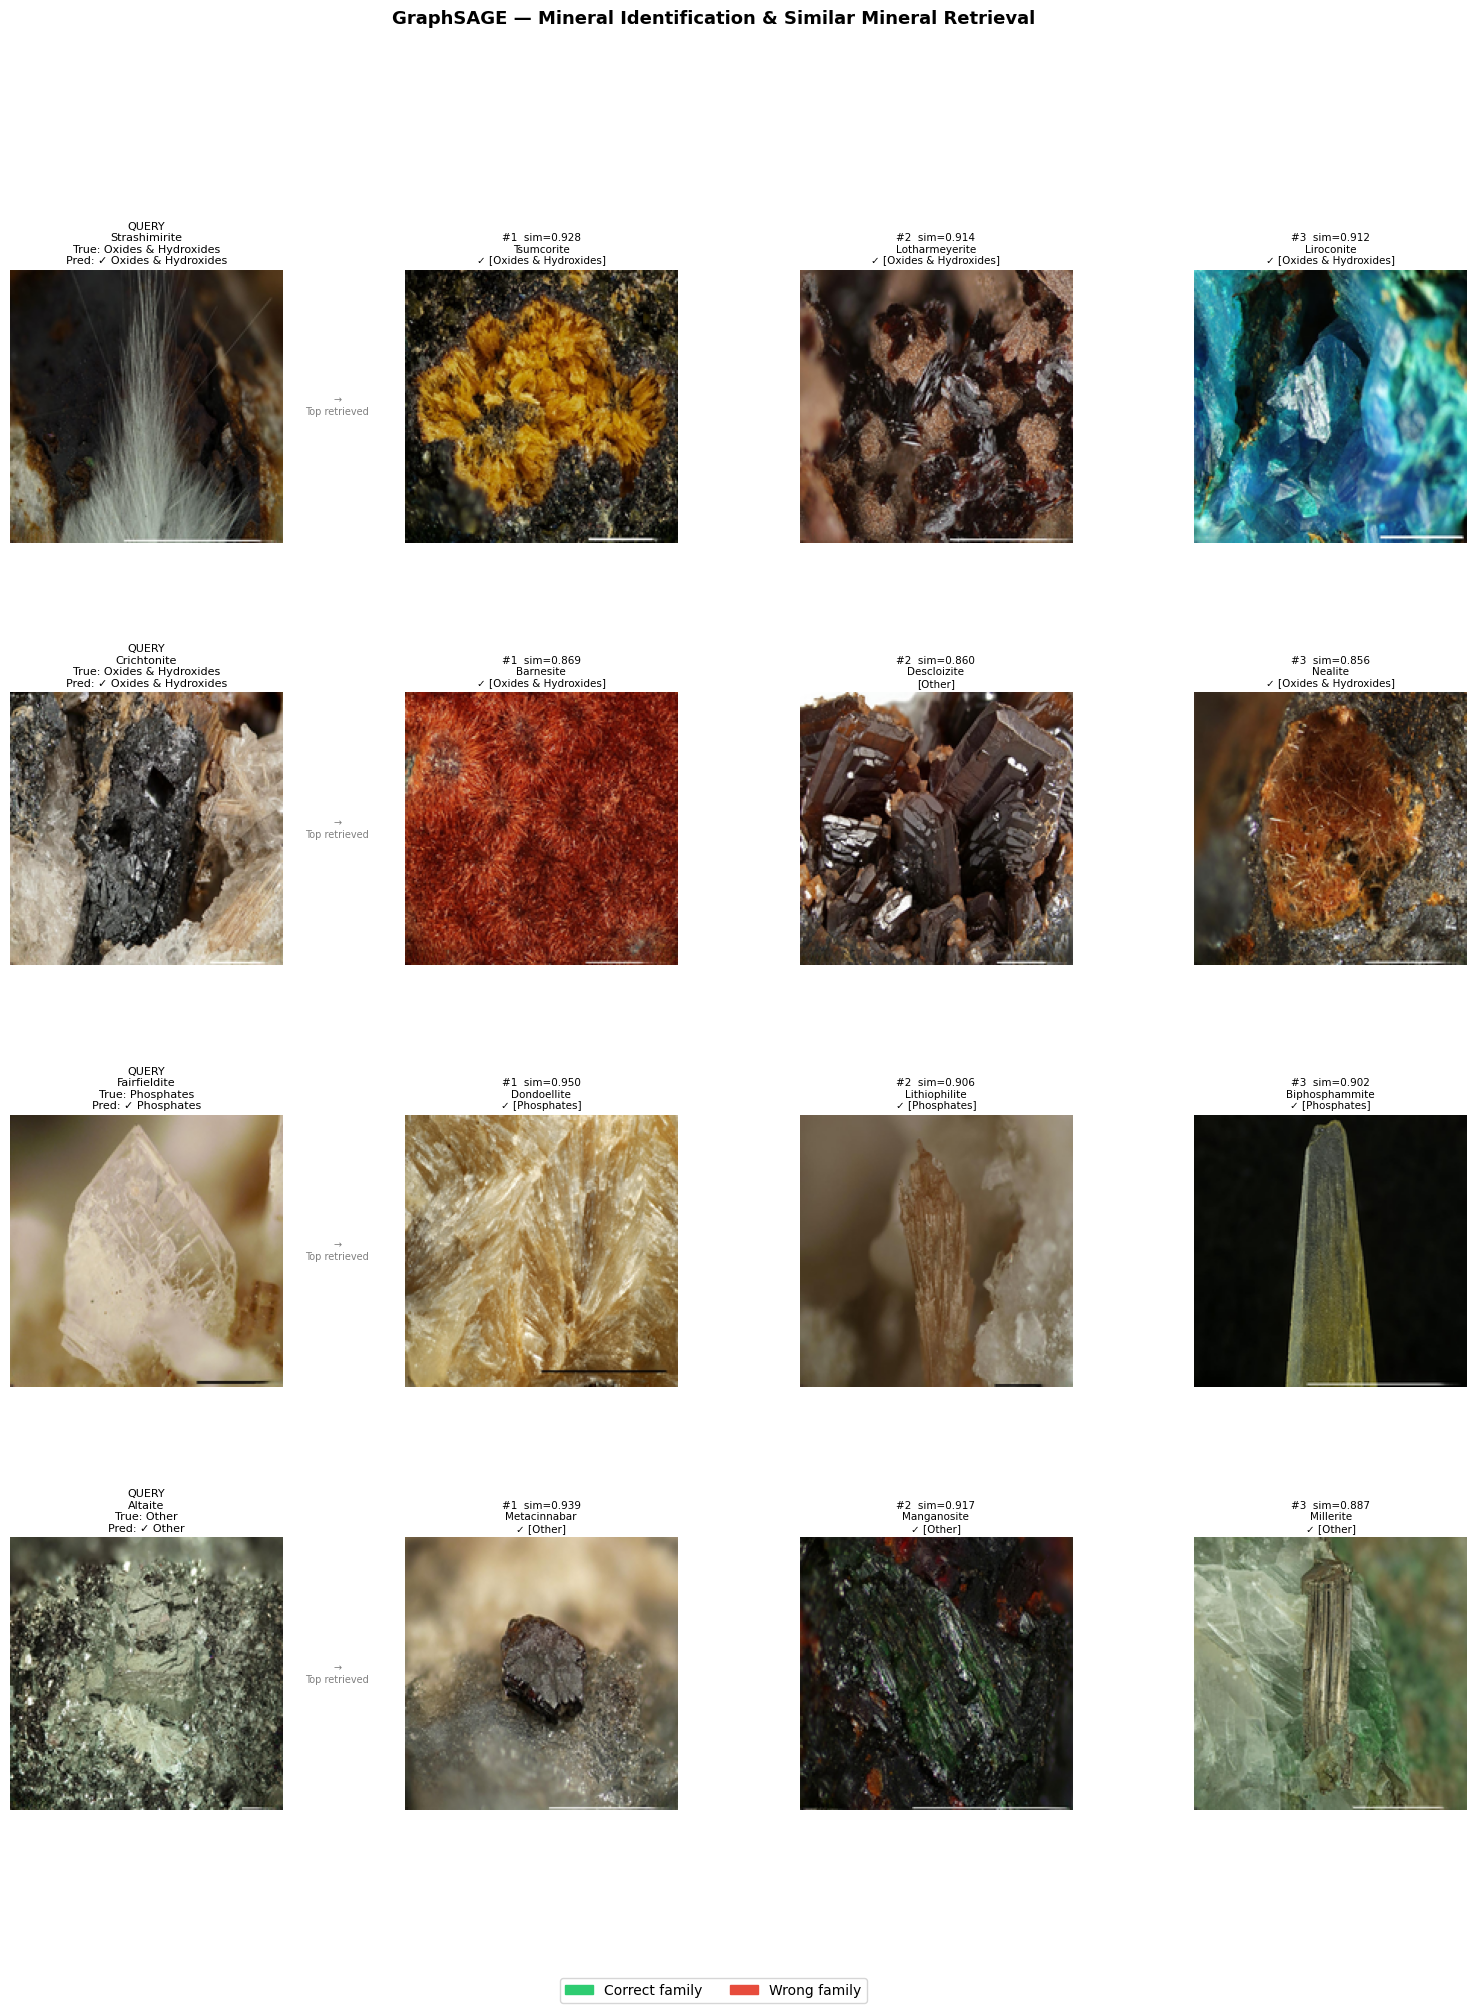

Saved visual_demo.png to Drive.


In [ ]:
#visual identification & retrieval demo
'''
For a handful of test minerals:
   - Shows the query specimen photo
   - Predicted family (GraphSAGE) vs. true family
   - Top-3 retrieved similar minerals with their photos

Requires: all variables from Cells 2–13 still in memory
   (sage, data, sim_matrix, final_ids, mineral_names, families,
    data.y_family, le_family, DEVICE, IMAGE_DIR)
'''

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from PIL import Image
import random

# ── Config ────────────────────────────────────────────────────────────────────
IMAGE_DIR  = Path("/content/drive/My Drive/Classes/2026 Spring/advanced ml/rruff_processed/rruff_clean_images")
N_DEMOS    = 4      # number of query minerals to show
TOP_K      = 3      # retrieved neighbors to display per query
RANDOM_SEED = 7

# ── Build RRUFF ID -> image path lookup (fast glob once) ─────────────────────
print("Building image path lookup...")
id_to_img_path = {}
for p in IMAGE_DIR.iterdir():
    if p.suffix.lower() in ('.jpg', '.jpeg', '.png'):
        # Extract RRUFF ID: look for R followed by 6 digits anywhere in filename
        m = re.search(r'(R\d{6})', p.name, re.IGNORECASE)
        if m:
            rid = m.group(1).upper()
            if rid not in id_to_img_path:
                id_to_img_path[rid] = p
print(f"Found images for {len(id_to_img_path)} unique RRUFF IDs.")

def load_img(rruff_id, size=(180, 180)):
    """Load and resize a specimen image, return None if not found."""
    p = id_to_img_path.get(rruff_id.upper())
    if p is None:
        return None
    try:
        return Image.open(p).convert('RGB').resize(size, Image.LANCZOS)
    except Exception:
        return None

def make_placeholder(size=(180, 180), text="No image"):
    """Gray placeholder when image is missing."""
    img = Image.new('RGB', size, color=(200, 200, 200))
    return img

# ── Get model predictions for all test nodes ──────────────────────────────────
sage.eval()
with torch.no_grad():
    all_logits = sage(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu()
    all_preds  = all_logits.argmax(dim=-1)         # (N,) predicted family idx
    all_embs   = sage.embed(data.x.to(DEVICE), data.edge_index.to(DEVICE)).cpu()

sim_matrix = all_embs @ all_embs.t()              # (N, N) cosine similarities

# ── Pick demo queries — prefer ones with images available ─────────────────────
test_idx = data.test_mask.nonzero(as_tuple=True)[0].tolist()
random.seed(RANDOM_SEED)
random.shuffle(test_idx)

demo_queries = []
for qi in test_idx:
    rid = final_ids[qi]
    if rid.upper() in id_to_img_path:
        demo_queries.append(qi)
    if len(demo_queries) == N_DEMOS:
        break

if len(demo_queries) < N_DEMOS:
    print(f"Warning: only found {len(demo_queries)} test minerals with images.")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(5 * (TOP_K + 1), 5 * len(demo_queries)))
outer_gs = GridSpec(len(demo_queries), 1, figure=fig, hspace=0.55)

for row, qi in enumerate(demo_queries):
    rid        = final_ids[qi]
    name       = mineral_names[qi]
    true_fam   = families[qi]
    pred_fam   = le_family.inverse_transform([all_preds[qi].item()])[0]
    correct    = (true_fam == pred_fam)

    # Top-K neighbors (excluding self and duplicate names for cleaner demo)
    scores = sim_matrix[qi].clone()
    scores[qi] = -1.0
    ranked = scores.argsort(descending=True).tolist()

    neighbors = []
    seen_names = set()
    for ni in ranked:
        n_name = mineral_names[ni]
        if n_name not in seen_names:
            neighbors.append(ni)
            seen_names.add(n_name)
        if len(neighbors) == TOP_K:
            break

    # Inner grid: query col + TOP_K neighbor cols
    inner_gs = outer_gs[row].subgridspec(1, TOP_K + 1, wspace=0.08)

    #Query panel
    ax_q = fig.add_subplot(inner_gs[0, 0])
    img_q = load_img(rid) or make_placeholder()
    ax_q.imshow(img_q)
    ax_q.axis('off')

    border_color = '#2ecc71' if correct else '#e74c3c'
    for spine in ax_q.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
        spine.set_visible(True)

    pred_label = f"✓ {pred_fam}" if correct else f"✗ {pred_fam}"
    ax_q.set_title(
        f"QUERY\n{name}\n"
        f"True: {true_fam}\n"
        f"Pred: {pred_label}",
        fontsize=8, loc='center',
        color='black', pad=4
    )

    # Separator label
    ax_q.text(1.20, 0.5, '→\nTop retrieved',
              transform=ax_q.transAxes,
              ha='center', va='center',
              fontsize=7, color='gray',
              rotation=0)

    #Neighbor panels
    for col, ni in enumerate(neighbors, start=1):
        ax_n = fig.add_subplot(inner_gs[0, col])
        n_rid  = final_ids[ni]
        n_name = mineral_names[ni]
        n_fam  = families[ni]
        sim_score = sim_matrix[qi, ni].item()

        img_n = load_img(n_rid) or make_placeholder()
        ax_n.imshow(img_n)
        ax_n.axis('off')

        fam_match = (n_fam == true_fam)
        n_color = '#2ecc71' if fam_match else '#e74c3c'
        for spine in ax_n.spines.values():
            spine.set_edgecolor(n_color)
            spine.set_linewidth(2)
            spine.set_visible(True)

        fam_tag = f"[{n_fam}]" if not fam_match else f"✓ [{n_fam}]"
        ax_n.set_title(
            f"#{col}  sim={sim_score:.3f}\n{n_name}\n{fam_tag}",
            fontsize=7.5, loc='center', pad=4
        )

#legend
correct_patch = mpatches.Patch(color='#2ecc71', label='Correct family')
wrong_patch = mpatches.Patch(color='#e74c3c', label='Wrong family')
fig.legend(
    handles=[correct_patch, wrong_patch],
    loc='lower center', ncol=2,
    fontsize=10, frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle('GraphSAGE — Mineral Identification & Similar Mineral Retrieval',fontsize=13, fontweight='bold', y=1.01)
plt.savefig(BASE / 'visual_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved visual_demo.png to Drive.")

In [ ]:
print(f"Avg degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Isolated nodes (degree 0): {(torch.diff(data.edge_index[0].sort()[0]).eq(0).logical_not().sum()).item()}")

Avg degree: 180.12
Isolated nodes (degree 0): 1198


In [ ]:
from collections import Counter
name_counts = Counter(mineral_names)
dupes = {name: count for name, count in name_counts.items() if count > 1}
print(f"Minerals with duplicate nodes: {len(dupes)}")
for name, count in sorted(dupes.items(), key=lambda x: -x[1])[:10]:
    print(f"  {name}: {count} nodes")

Minerals with duplicate nodes: 0
